Data preview:
            Timestamp  Index       True       Pred  Match
0 2026-01-13 19:42:26      0  Karacadag  Karacadag      1
1 2026-01-13 19:42:28      1  Karacadag  Karacadag      1
2 2026-01-13 19:42:29      2    Jasmine    Arborio      0
3 2026-01-13 19:42:30      3    Basmati    Basmati      1
4 2026-01-13 19:42:32      4    Jasmine     Ipsala      0
Overall Accuracy: 67.50%

Accuracy per class:
True
Arborio      0.574074
Basmati      0.786885
Ipsala       1.000000
Jasmine      0.045918
Karacadag    0.967742
Name: Match, dtype: float64


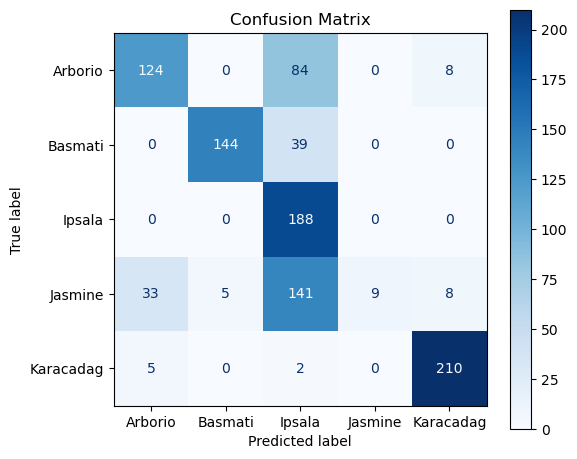

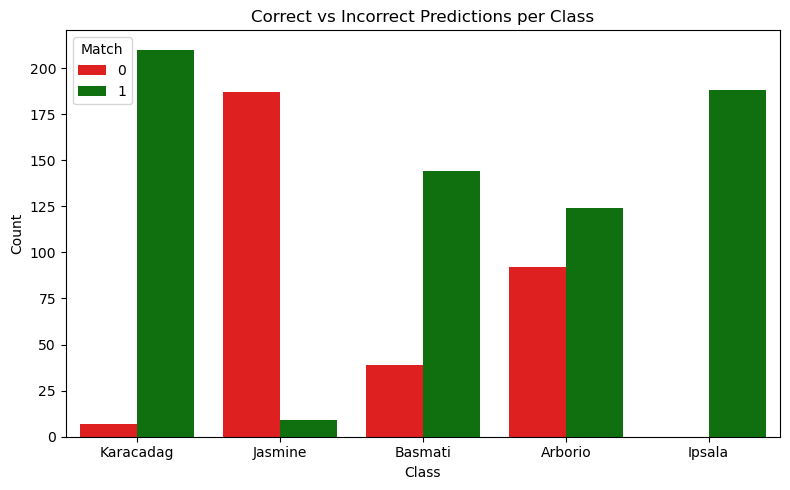

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ---------- Load Data ----------
csv_file = "rice_results.csv"  # replace with your CSV path
df = pd.read_csv(csv_file, parse_dates=['Timestamp'])

print("Data preview:")
print(df.head())

# ---------- Overall Accuracy ----------
overall_acc = df['Match'].mean()
print(f"Overall Accuracy: {overall_acc*100:.2f}%")

# ---------- Accuracy per Class ----------
class_acc = df.groupby('True')['Match'].mean()
print("\nAccuracy per class:")
print(class_acc)

# ---------- Confusion Matrix ----------
labels = sorted(df['True'].unique())  # sorted class labels
cm = confusion_matrix(df['True'], df['Pred'], labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

plt.figure(figsize=(6,5))
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


# ---------- Counts per class ----------
plt.figure(figsize=(8,5))
sns.countplot(x='True', hue='Match', data=df, palette={1:'green',0:'red'})
plt.title("Correct vs Incorrect Predictions per Class")
plt.ylabel("Count")
plt.xlabel("Class")
plt.tight_layout()
plt.show()
